<a href="https://colab.research.google.com/github/4cekay/B101-Group2-NLP-Project/blob/backup-points/DetectorModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Setup**

In [1]:
!pip install numpy torch datasets transformers sentencepiece protobuf accelerate evaluate tensorboard scikit-learn

In [2]:
import os
import pandas as pd
import numpy as np
import evaluate
from datasets import Dataset, DatasetDict, load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, IntervalStrategy, EarlyStoppingCallback
import torch
from sklearn.model_selection import train_test_split
import huggingface_hub
from collections import Counter
from sklearn.metrics import roc_curve, auc, roc_auc_score, f1_score, confusion_matrix, precision_recall_curve, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import json


# **Dataset**

Informal Dataset, Formal Dataset:
- (Aug 5): 5400 samples**
  - 2700 human-written, 2700 AI-generated samples (900 / each sub-type/genre)
  - train_test_split (80/20) --> 4320 train / 1080 val

- Evaluation Set:
  - 2700 human-written, 2700 AI-generated samples (900 / each sub-type/genre)
  - Additional 1350 samples (same informal/formal setting and human/AI classes, different models/sources) for external validation --> 5400 train / 1350 val


Load our .csv dataset file(s) and convert into HF dataset format.

In [ ]:
# original train_test_split set
path= r"./dataset/formal_set_5400.csv"
df= pd.read_csv(path)

raw_dataset= Dataset.from_pandas(df)
raw_dataset = raw_dataset.class_encode_column("AI_label") # encode the AI_label column into type ClassLabel

print(raw_dataset)


Stringifying the column:   0%|          | 0/5400 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/5400 [00:00<?, ? examples/s]

Dataset({
    features: ['sample_text', 'sub-type', 'AI_label'],
    num_rows: 5400
})


In [ ]:
dataset = raw_dataset.train_test_split(test_size=0.2, seed=42, shuffle=True, stratify_by_column="AI_label")

# rename test set to val
dataset["val"] = dataset.pop("test")

dataset

DatasetDict({
    train: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label'],
        num_rows: 4320
    })
    val: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label'],
        num_rows: 1080
    })
})

Check our genre/source distributions in our datasets

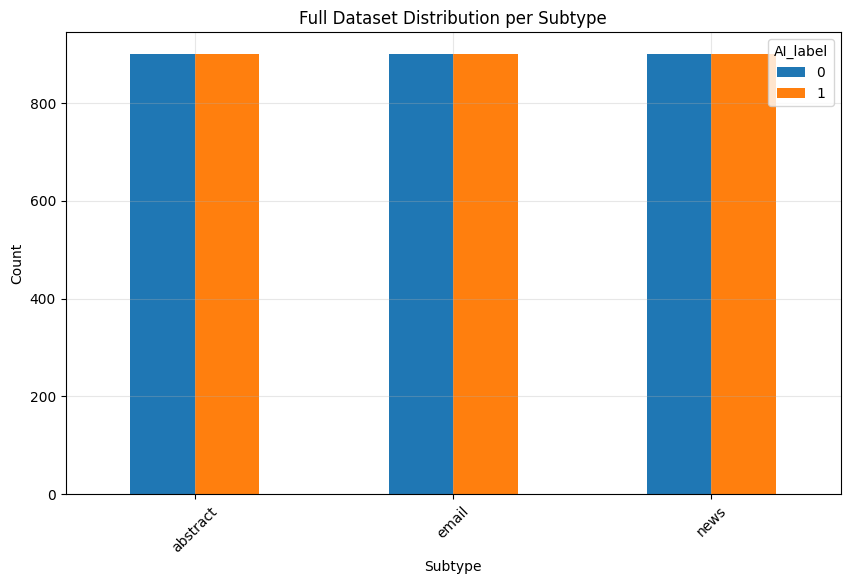

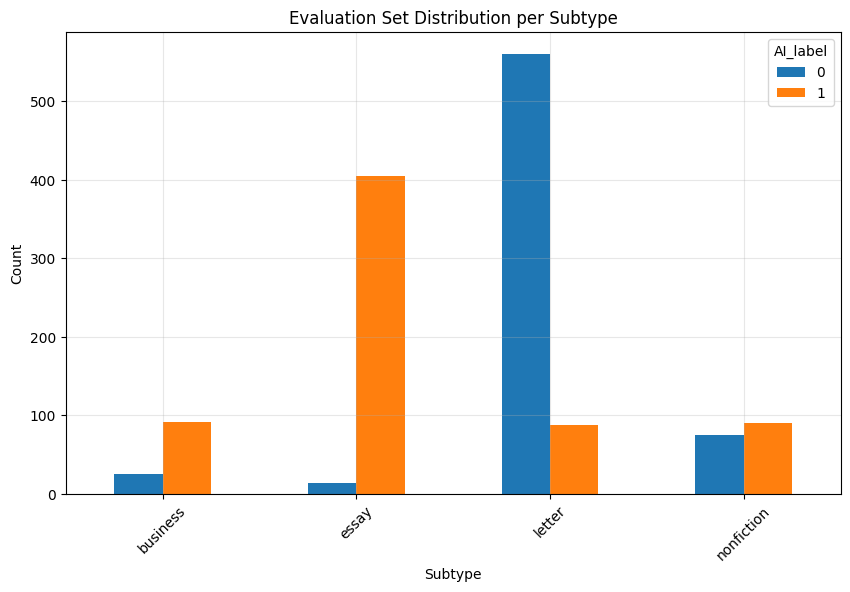

In [ ]:
# full dataset
df_5400_set = pd.read_csv("./dataset/formal_set_5400.csv")
subtype_counts = df_5400_set.groupby("sub-type")["AI_label"].value_counts().unstack(fill_value=0)

# visuals (for report)
subtype_counts.plot(kind="bar", figsize=(10,6))
plt.title("Full Dataset Distribution per Subtype")
plt.xlabel("Subtype")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

# evaluation set
df_eval_set = pd.read_csv("./dataset/formal_val_1350.csv")
subtype_counts = df_eval_set.groupby("sub-type")["AI_label"].value_counts().unstack(fill_value=0)

# visuals (for report)
subtype_counts.plot(kind="bar", figsize=(10,6))
plt.title("Evaluation Set Distribution per Subtype")
plt.xlabel("Subtype")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()


## **70/15/15**

In [3]:
df = pd.read_csv("./dataset/formal_set_5400.csv")

df["strat"] = df["sub-type"].astype(str) + "_" + df["AI_label"].astype(str)

# 70% train, 30% temp (for val/test)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["strat"],
    random_state=42
)

# 15% val, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["strat"],
    random_state=42
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

# Optional: check distributions
print("\nTrain distribution:\n", train_df.groupby(["sub-type","AI_label"]).size())
print("\nVal distribution:\n", val_df.groupby(["sub-type","AI_label"]).size())
print("\nTest distribution:\n", test_df.groupby(["sub-type","AI_label"]).size())


Train size: 3780
Val size: 810
Test size: 810

Train distribution:
 sub-type  AI_label
abstract  0           630
          1           630
email     0           630
          1           630
news      0           630
          1           630
dtype: int64

Val distribution:
 sub-type  AI_label
abstract  0           135
          1           135
email     0           135
          1           135
news      0           135
          1           135
dtype: int64

Test distribution:
 sub-type  AI_label
abstract  0           135
          1           135
email     0           135
          1           135
news      0           135
          1           135
dtype: int64


In [4]:
# turn into HF dataset object
train_dataset = Dataset.from_pandas(train_df)
val_dataset   = Dataset.from_pandas(val_df)
test_dataset  = Dataset.from_pandas(test_df)

# compile all 3 splits into one dataset
formal_dataset = DatasetDict({
    "train": train_dataset,
    "val": val_dataset,
    "test": test_dataset
})

print(formal_dataset)


DatasetDict({
    train: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label', 'strat', '__index_level_0__'],
        num_rows: 3780
    })
    val: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label', 'strat', '__index_level_0__'],
        num_rows: 810
    })
    test: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label', 'strat', '__index_level_0__'],
        num_rows: 810
    })
})


# **Fine-Tuning Prep**

## **Tokenization**

In [5]:
# Load tokenizer needed by the base model

model = "microsoft/deberta-v3-small"
tokenizer = AutoTokenizer.from_pretrained(model, use_fast=True)

tokenizer

DebertaV2Tokenizer(name_or_path='microsoft/deberta-v3-small', vocab_size=128000, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '[CLS]', 'eos_token': '[SEP]', 'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128000: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

**Note: **DeBERTa V3 uses SentencePiece tokenization instead of Standard BPE and Unigram, which tokenizes raw characters (rather than getting treated like a boundary to help create words) >>> token count != word count.

In [6]:
def tokenize(example):
  tokenized = tokenizer(example["sample_text"], truncation=True, padding="max_length", max_length=350) # 512 is the max, though the dataset should be safe enough from cleaning
  tokenized["labels"] = example["AI_label"]
  return tokenized

In [33]:
clean_test_dataset = Dataset.from_pandas(clean_test_df)
clean_test_dataset

Dataset({
    features: ['sample_text', 'sub-type', 'AI_label', 'strat', 'text_hash'],
    num_rows: 807
})

In [37]:
tokenized_clean_dataset = clean_test_dataset.map(tokenize, batched=True, remove_columns=['text_hash','sample_text', 'sub-type', 'AI_label', 'strat'])
tokenized_clean_dataset

Map:   0%|          | 0/807 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 807
})

In [45]:
external_df = pd.read_csv("./dataset/formal_val_1350.csv")

external_dataset = Dataset.from_pandas(external_df)

In [47]:
tokenized_external_dataset = external_dataset.map(tokenize, batched=True, remove_columns=['sample_text', 'sub-type', 'AI_label'])
tokenized_external_dataset

Map:   0%|          | 0/1350 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 1350
})

## **Metrics**

### **Functions Setup** (compute_metrics)

In [ ]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis=-1)
  accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
  f1 = f1_metric.compute(predictions=predictions, references=labels)
  return {**accuracy, **f1}

In [8]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    # Accuracy
    accuracy = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]

    # Precision, Recall, F1 (macro + weighted)
    precision, recall, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    # ROC AUC
    try:
        auc = roc_auc_score(labels, logits[:,1])
    except ValueError:
        auc = float("nan")

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "precision_macro": precision,
        "recall_macro": recall,
        "auc": auc,
    }

### **Metric Graphs**

Fine-tuning Results

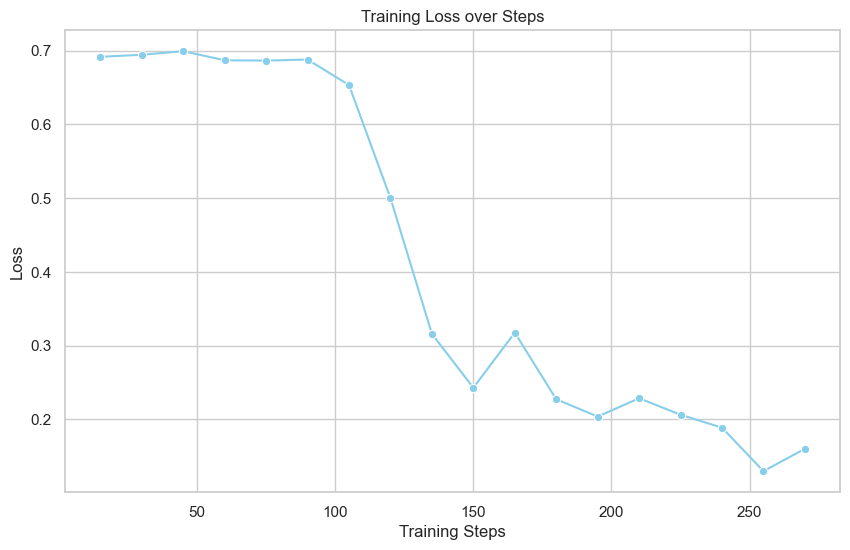

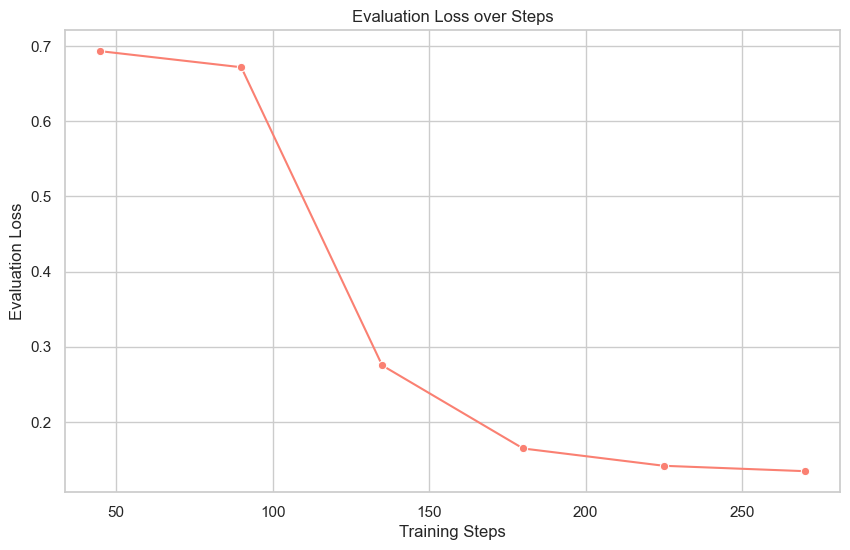

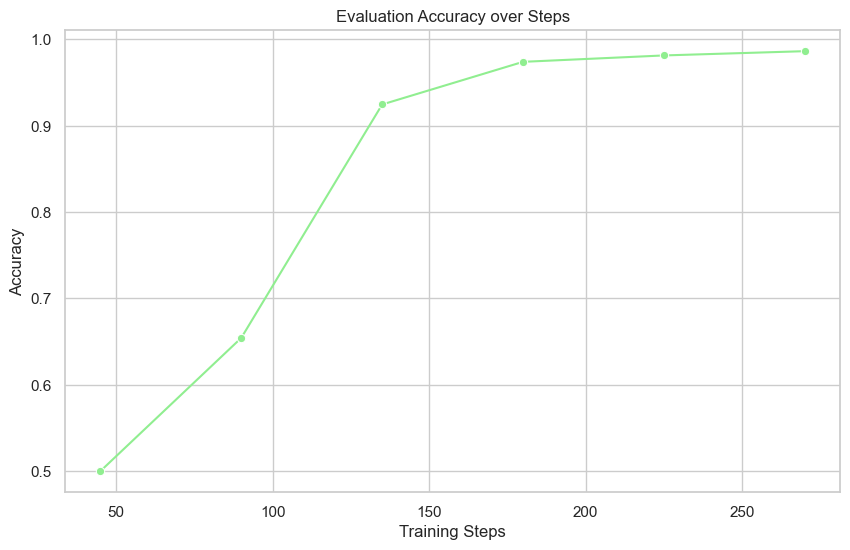

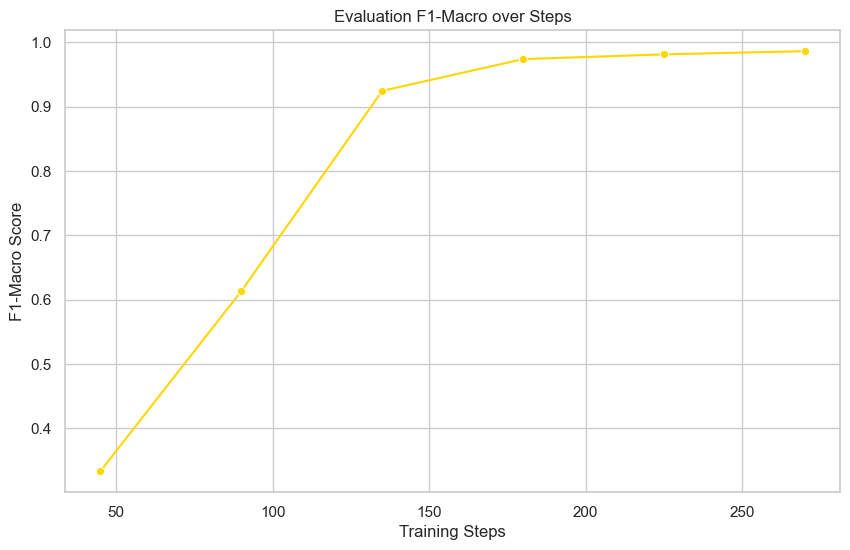

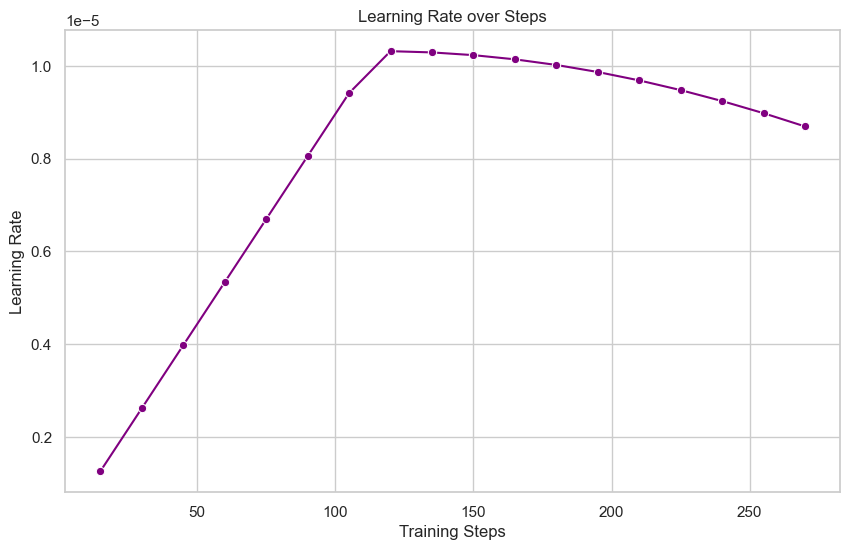

In [27]:
# metric charts from logged steps in "best model" checkpoints

output_dir = './finetune_metrics_newest'
os.makedirs(output_dir, exist_ok=True)

trainer_state_path = "./runs/deberta_v3_interpolate_test/checkpoint-270/trainer_state.json"
with open(trainer_state_path, 'r', encoding='utf-8') as file:
    trainer_state = json.load(file)

log_history = trainer_state.get('log_history', [])

# training vs. val steps
train_logs = [log for log in log_history if 'loss' in log and 'eval_loss' not in log]
eval_logs = [log for log in log_history if 'eval_loss' in log]

# extract training metrics
train_steps = [log['step'] for log in train_logs]
train_loss = [log['loss'] for log in train_logs]
train_learning_rate = [log['learning_rate'] for log in train_logs]

# extract evaluation metrics
eval_steps = [log['step'] for log in eval_logs]
eval_loss = [log['eval_loss'] for log in eval_logs]
eval_accuracy = [log['eval_accuracy'] for log in eval_logs]
eval_f1_macro = [log['eval_f1_macro'] for log in eval_logs]

sns.set_theme(style="whitegrid")

# train loss
plt.figure(figsize=(10, 6))
sns.lineplot(x=train_steps, y=train_loss, marker='o', color='skyblue')
plt.title('Training Loss over Steps')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'training_loss.png'))
plt.show()

# eval loss
plt.figure(figsize=(10, 6))
sns.lineplot(x=eval_steps, y=eval_loss, marker='o', color='salmon')
plt.title('Evaluation Loss over Steps')
plt.xlabel('Training Steps')
plt.ylabel('Evaluation Loss')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'eval_loss.png'))
plt.show()

# eval acc
plt.figure(figsize=(10, 6))
sns.lineplot(x=eval_steps, y=eval_accuracy, marker='o', color='lightgreen')
plt.title('Evaluation Accuracy over Steps')
plt.xlabel('Training Steps')
plt.ylabel('Accuracy')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'eval_accuracy.png'))
plt.show()

# eval F1 (macro)
plt.figure(figsize=(10, 6))
sns.lineplot(x=eval_steps, y=eval_f1_macro, marker='o', color='gold')
plt.title('Evaluation F1-Macro over Steps')
plt.xlabel('Training Steps')
plt.ylabel('F1-Macro Score')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'eval_f1_macro.png'))
plt.show()

# plot learning rate
plt.figure(figsize=(10, 6))
sns.lineplot(x=train_steps, y=train_learning_rate, marker='o', color='purple')
plt.title('Learning Rate over Steps')
plt.xlabel('Training Steps')
plt.ylabel('Learning Rate')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'learning_rate.png'))
plt.show()

External Evaluation Results

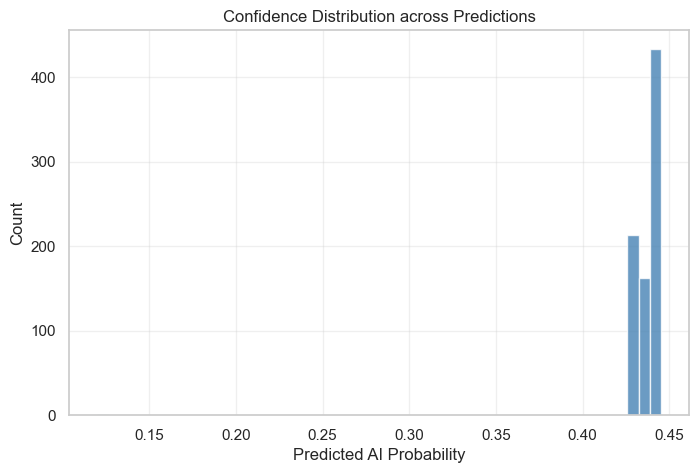

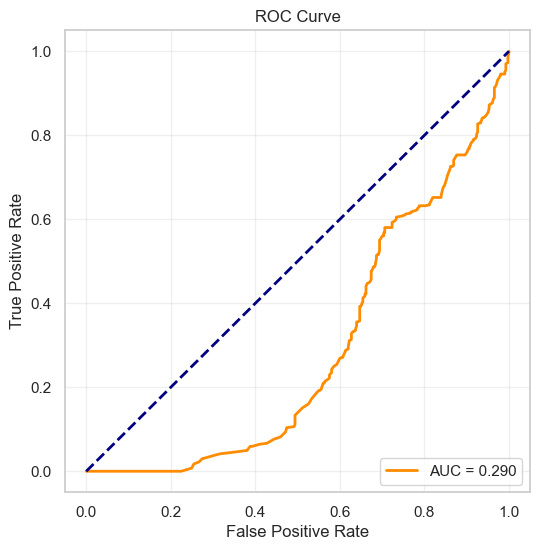

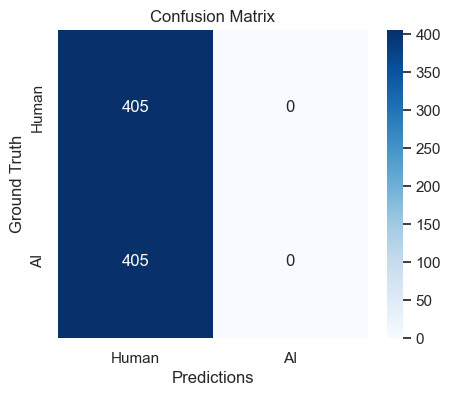

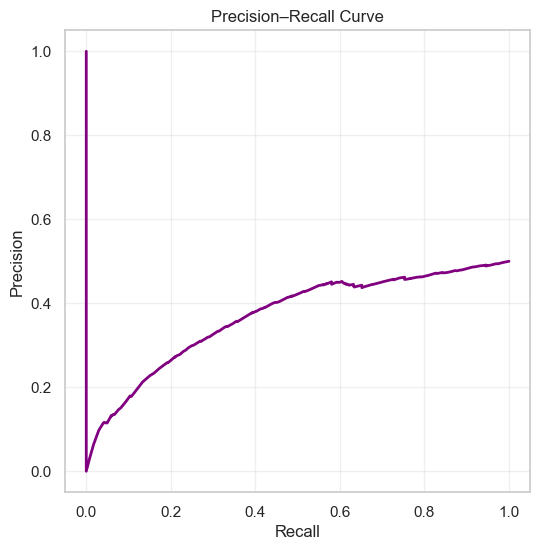

In [34]:
output_dir = './eval_metrics_newest'
os.makedirs(output_dir, exist_ok=True)

# AI confidence
plt.figure(figsize=(8,5))
plt.hist(prob_ai, bins=50, color='steelblue', alpha=0.8)
plt.title("Confidence Distribution across Predictions")
plt.xlabel("Predicted AI Probability")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(output_dir, 'external_ai_probs.png'))
plt.show()

#roc-auc
fpr, tpr, _ = roc_curve(labels, prob_ai)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(output_dir, 'external_roc_auc.png'))
plt.show()

# confusion matrix
cm = confusion_matrix(labels, predicted_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Human", "AI"],
            yticklabels=["Human", "AI"])
plt.xlabel("Predictions")
plt.ylabel("Ground Truth")
plt.title("Confusion Matrix")
plt.savefig(os.path.join(output_dir, 'external_confusion_matrix.png'))
plt.show()

# p-r
precision, recall, _ = precision_recall_curve(labels, prob_ai)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, lw=2, color='purple')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(output_dir, 'external_pr.png'))
plt.show()


In [ ]:
df_eval = pd.DataFrame({
    "label": labels,
    "pred": predicted_classes,
    "prob_ai": prob_ai,
    "subtype": tokenized_external_dataset["subtype"]
})

subtype_scores = []

for subtype, g in df_eval.groupby("subtype"):
    if len(g) < 10:
        continue
    auc = roc_auc_score(g["label"], g["prob_ai"])
    f1 = f1_score(g["label"], g["pred"])
    subtype_scores.append((subtype, auc, f1))

sub_df = pd.DataFrame(subtype_scores, columns=["subtype", "auc", "f1"])

plt.figure(figsize=(10,5))
plt.bar(sub_df["subtype"], sub_df["auc"], color='teal')
plt.xticks(rotation=45)
plt.ylabel("AUC")
plt.title("AUC per Subtype")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10,5))
plt.bar(sub_df["subtype"], sub_df["f1"], color='salmon')
plt.xticks(rotation=45)
plt.ylabel("F1 Score")
plt.title("F1 per Subtype")
plt.grid(alpha=0.3)
plt.show()


ValueError: Column 'subtype' doesn't exist.

## **Training Config**

In [24]:
model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-small",
    num_labels=2,
    id2label={0: "Human-Written", 1: "AI-Generated"},
    label2id={"Human-Written": 0, "AI-Generated": 1},
    dtype=torch.float32, # very important T^T she blows up and dies otherwise
    #hidden_dropout_prob=0.15,          # trial, default is 0.1
    #attention_probs_dropout_prob=0.15, # trial, default is 0.1
)

# for tensorboard
os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs/interpolate_test"

final_training_args = TrainingArguments(
    seed=42,
    output_dir="./runs/deberta_v3_interpolate_test",
    report_to = "tensorboard",

    # Optuna Best Parameters
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=1.0317e-05,
    weight_decay=0.02586,
    warmup_steps=114,
    label_smoothing_factor=0.04114,

    lr_scheduler_type="cosine",
    optim="adamw_torch_fused" if torch.cuda.is_available() else "adamw_torch",
    adam_epsilon=1e-6,
    max_grad_norm=0.5,

    fp16=False,
    bf16=torch.cuda.is_bf16_supported(),

    eval_strategy="steps",
    eval_steps=45,
    save_strategy="steps",
    save_steps=45,
    save_total_limit=1,
    logging_steps=15,

    metric_for_best_model="accuracy",
    greater_is_better=True,
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=final_training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["val"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifie

# **Fine-Tuning an AI-Text Detector**

## **Tensorboard**
For viewing train/eval metrics + graphs

**Local:**

Not sure on Google runtime, but locally, it times out in the notebook for me so I don't recommend running it here.

- In command line/terminal, go to your working directory
- **tensorboard --logdir=./logs --port=6006**
- Access localhost in browser


### **Prelim Settings Rerun**

To retrieve proper metrics (tensorboard bug) and save run (lost logs to crash).
- Note: Specifically BEFORE dtype fix, so collapsing results are expected.

In [ ]:
checkpoint = "microsoft/deberta-v3-small"
num_labels = 2
id2label = {0:"Human-Written", 1:"AI-Generated"}
label2id = {"Human-Written":0, "AI-Generated":1}
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    dtype=torch.float32 # change
)

# for tensorboard
os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs"

training_args = TrainingArguments(
    seed=42,
    output_dir="./runs/deberta_v3_small_dtype",
    logging_dir="./logs/dtype",
    logging_steps=20,

    report_to = "tensorboard",

    num_train_epochs=4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.05,

    lr_scheduler_type="linear",
    warmup_steps=50,

    eval_strategy="steps",
    eval_steps = 85,
    save_strategy="steps",
    save_steps = 85,
    save_total_limit = 2,

    max_grad_norm=1.0,
    fp16=True,

    metric_for_best_model="eval_loss",
    greater_is_better=False,
    load_best_model_at_end=True,

)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifie

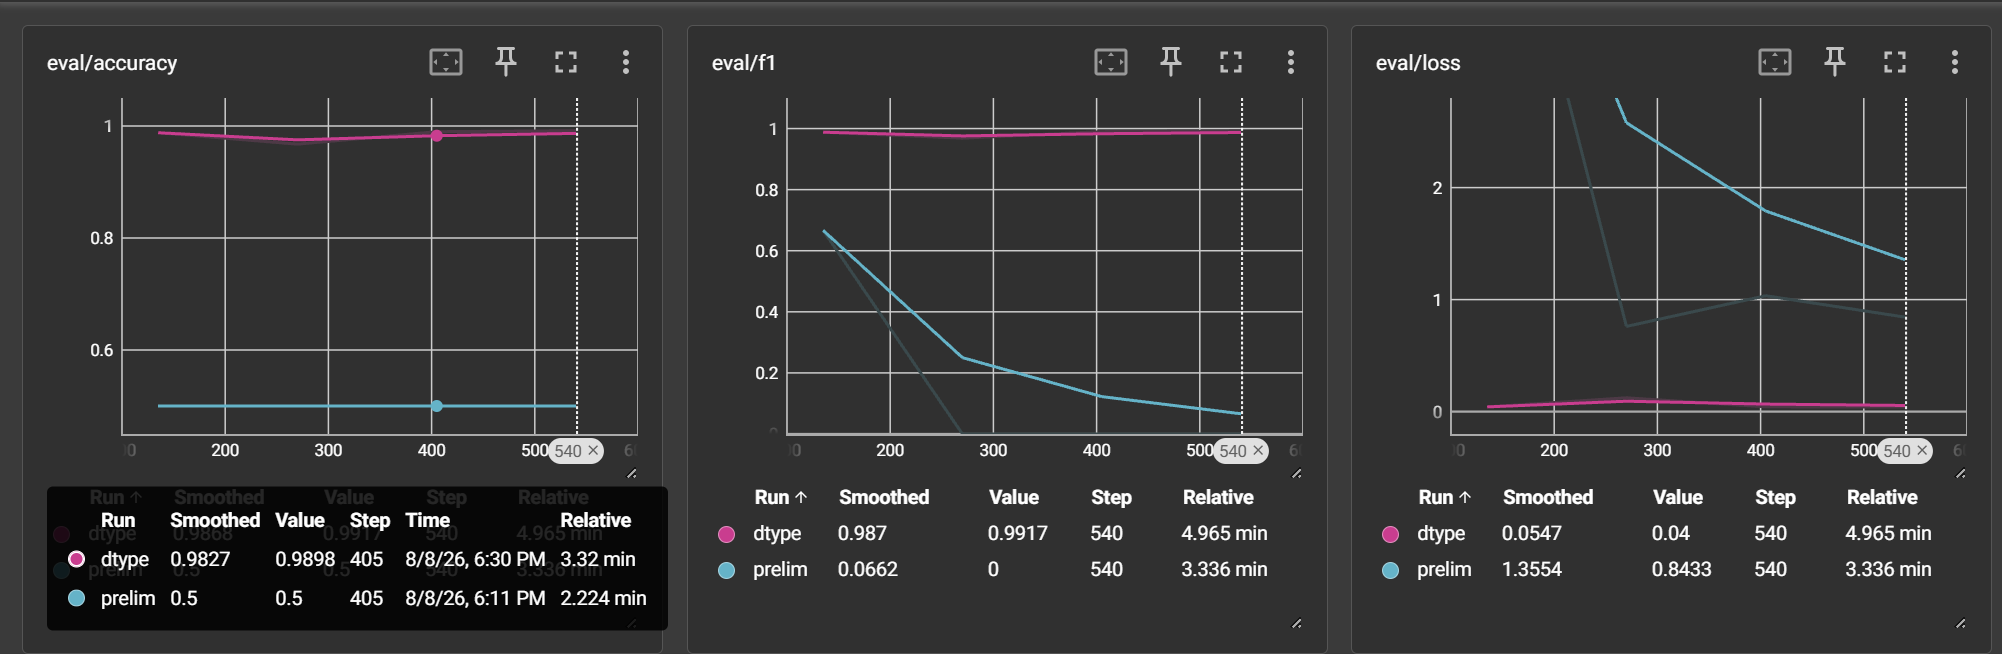

Prelim Run (post-fp16, emergency dataset cleaning fixes) on Formal Dataset

In [ ]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1
50,0.694851,0.683622,0.500000,0.000000
100,0.321564,0.243215,0.898148,0.902998
150,0.208967,0.113891,0.962037,0.963360
200,0.058592,0.074021,0.978704,0.978995
250,0.047767,0.146977,0.968519,0.969424
300,0.027279,0.060348,0.986111,0.986276
350,0.052604,0.035808,0.989815,0.989843
400,0.001787,0.051619,0.987963,0.988040
450,0.082203,0.040964,0.990741,0.990689
500,0.037807,0.081352,0.984259,0.984389


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1080, training_loss=0.0884912511323044, metrics={'train_runtime': 1297.1526, 'train_samples_per_second': 13.321, 'train_steps_per_second': 0.833, 'total_flos': 2289118186045440.0, 'train_loss': 0.0884912511323044, 'epoch': 4.0})

### **(1) Interpolation Test**

Testing the fine-tuned model on unseen data from WITHIN ITS OWN SET, to test in-house generalization.

70/15/15 Split: Train and Val

In [25]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,Auc
45,0.699251,0.693334,0.500000,0.333333,0.333333,0.250000,0.500000,0.788593
90,0.687906,0.671936,0.654321,0.613236,0.613236,0.768343,0.654321,0.863335
135,0.316040,0.275055,0.924691,0.924658,0.924658,0.925441,0.924691,0.979290
180,0.227405,0.164469,0.974074,0.974074,0.974074,0.974100,0.974074,0.995482
225,0.206397,0.141412,0.981481,0.981481,0.981481,0.981508,0.981481,0.998086
270,0.160249,0.134260,0.986420,0.986420,0.986420,0.986423,0.986420,0.997994
315,0.120154,0.150553,0.982716,0.982715,0.982715,0.982822,0.982716,0.997159
360,0.114552,0.133935,0.986420,0.986420,0.986420,0.986446,0.986420,0.996110
405,0.135640,0.131071,0.986420,0.986419,0.986419,0.986494,0.986420,0.998043
450,0.136041,0.140269,0.986420,0.986419,0.986419,0.986494,0.986420,0.998314


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=450, training_loss=0.30206947088241576, metrics={'train_runtime': 169.8306, 'train_samples_per_second': 66.772, 'train_steps_per_second': 4.187, 'total_flos': 650924516743200.0, 'train_loss': 0.30206947088241576, 'epoch': 1.8987341772151898})

In [9]:
# --- step budget breakdown, from actual split sizes ---
train_size = len(tokenized_dataset["train"])   # expect ~3780 for a 70% split of 5400
batch_size = 16
steps_per_epoch = -(-train_size // batch_size)  # ceil division

num_train_epochs = 5
total_steps = steps_per_epoch * num_train_epochs

eval_steps = max(50, steps_per_epoch // 6)          # ~6 evals per epoch
warmup_steps = int(0.06 * total_steps)              # 6% warmup, proportional not borrowed
patience_evals = max(4, -(-int(1.5 * steps_per_epoch) // eval_steps))  # >=1.5 epochs runway

print(f"train_size={train_size}")
print(f"steps_per_epoch={steps_per_epoch}")
print(f"total_steps={total_steps}")
print(f"eval_steps={eval_steps}")
print(f"warmup_steps={warmup_steps}")
print(f"patience_evals={patience_evals}  (guarantees {patience_evals*eval_steps} steps runway)")

# expected, for train_size ≈ 3780, batch_size=16:
#   steps_per_epoch ≈ 237
#   total_steps (5 epochs) ≈ 1185
#   eval_steps ≈ 50
#   warmup_steps ≈ 71
#   patience_evals ≈ 8  (400 steps guaranteed runway)

train_size=3780
steps_per_epoch=237
total_steps=1185
eval_steps=50
warmup_steps=71
patience_evals=8  (guarantees 400 steps runway)


In [13]:
model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-small",
    num_labels=2,
    id2label={0: "Human-Written", 1: "AI-Generated"},
    label2id={"Human-Written": 0, "AI-Generated": 1},
    dtype=torch.float32,
)

os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs/interpolate_test_v2"

final_training_args = TrainingArguments(
    seed=42,
    output_dir="./runs/deberta_v3_interpolate_test_v2",
    report_to="tensorboard",

    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=32,


    learning_rate=2e-5,
    weight_decay=0.01,
    lr_scheduler_type="linear",
    warmup_steps=warmup_steps,
    label_smoothing_factor=0.0, # off, to isolate the eval/loss drift question

    optim="adamw_torch_fused" if torch.cuda.is_available() else "adamw_torch",
    max_grad_norm=1.0,

    fp16=False,
    bf16=torch.cuda.is_bf16_supported(),

    eval_strategy="steps",
    eval_steps=eval_steps,
    save_strategy="steps",
    save_steps=eval_steps,
    save_total_limit=1,
    logging_steps=15,

    metric_for_best_model="accuracy",
    greater_is_better=True,
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=final_training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["val"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=patience_evals)]
)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.de

In [14]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,Auc
50,0.692437,0.664644,0.819753,0.815428,0.815428,0.852828,0.819753,0.912001
100,0.179018,0.134362,0.950617,0.950603,0.950603,0.951156,0.950617,0.989739
150,0.127535,0.356956,0.916049,0.915488,0.915488,0.927400,0.916049,0.996921
200,0.050124,0.061678,0.981481,0.981480,0.981480,0.981625,0.981481,0.998799
250,0.023000,0.054483,0.988889,0.988889,0.988889,0.988892,0.988889,0.999116
300,0.059813,0.054802,0.987654,0.987654,0.987654,0.987761,0.987654,0.999101
350,0.001121,0.059649,0.991358,0.991358,0.991358,0.991385,0.991358,0.999329
400,0.000276,0.050339,0.992593,0.992593,0.992593,0.992605,0.992593,0.999634
450,0.030761,0.050701,0.992593,0.992593,0.992593,0.992605,0.992593,0.999607
500,0.000881,0.045735,0.992593,0.992593,0.992593,0.992605,0.992593,0.999649


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1050, training_loss=0.06908108162738028, metrics={'train_runtime': 378.0908, 'train_samples_per_second': 49.988, 'train_steps_per_second': 3.134, 'total_flos': 1517012730172800.0, 'train_loss': 0.06908108162738028, 'epoch': 4.430379746835443})

In [15]:
# immediately after training, evaluate using THIS trainer object explicitly —
# don't reload from disk, don't reuse a trainer from another cell
test_preds = trainer.predict(tokenized_clean_dataset)
test_logits = test_preds.predictions
test_labels = test_preds.label_ids
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()[:, 1]
test_preds_class = np.argmax(test_logits, axis=-1)

print("True label distribution:", Counter(test_labels.tolist()))
print("Predicted label distribution:", Counter(test_preds_class.tolist()))
print("AUC:", roc_auc_score(test_labels, test_probs))
print("F1:", f1_score(test_labels, test_preds_class))
print("Confusion matrix:\n", confusion_matrix(test_labels, test_preds_class))



True label distribution: Counter({0: 405, 1: 405})
Predicted label distribution: Counter({1: 410, 0: 400})
AUC: 0.9998780673677793
F1: 0.9914110429447853
Confusion matrix:
 [[399   6]
 [  1 404]]


In [48]:
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best metric:", trainer.state.best_metric)
# Quick model param check
for name, param in trainer.model.named_parameters():
    if param.requires_grad:
        print(name)
        break


Best checkpoint: ./runs/deberta_v3_interpolate_test_v2\checkpoint-650
Best metric: 0.9938271604938271
deberta.embeddings.word_embeddings.weight


In [39]:
clean_test_preds = trainer.predict(tokenized_clean_dataset)

clean_test_logits = clean_test_preds.predictions
clean_test_labels = clean_test_preds.label_ids

clean_test_probs = torch.softmax(
    torch.tensor(clean_test_logits), dim=-1
).numpy()[:, 1]

clean_test_preds_class = np.argmax(clean_test_logits, axis=-1)



In [40]:
clean_test_df = clean_test_df.reset_index(drop=True)

clean_test_df["label"] = clean_test_labels
clean_test_df["pred"] = clean_test_preds_class
clean_test_df["prob_ai"] = clean_test_probs


In [44]:
from sklearn.metrics import classification_report, roc_auc_score

for subtype, group in clean_test_df.groupby('sub-type'):
    print("Subtype:", subtype)
    print(classification_report(group['AI_label'], group['pred'], digits=4))
    try:
        print("AUC:", roc_auc_score(group['AI_label'], group['prob_ai']))
    except ValueError:
        print("AUC: not computable (single class present)")
    print("-"*40)


Subtype: abstract
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       135
           1     1.0000    1.0000    1.0000       135

    accuracy                         1.0000       270
   macro avg     1.0000    1.0000    1.0000       270
weighted avg     1.0000    1.0000    1.0000       270

AUC: 0.9999999999999999
----------------------------------------
Subtype: email
              precision    recall  f1-score   support

           0     0.9922    0.9697    0.9808       132
           1     0.9710    0.9926    0.9817       135

    accuracy                         0.9813       267
   macro avg     0.9816    0.9811    0.9813       267
weighted avg     0.9815    0.9813    0.9813       267

AUC: 0.9990460157126824
----------------------------------------
Subtype: news
              precision    recall  f1-score   support

           0     1.0000    0.9852    0.9925       135
           1     0.9854    1.0000    0.9926       135

    a

In [ ]:
seeds = [42, 7, 1234]
results = {}
for s in seeds:
    final_training_args.seed = s
    # re-init model and trainer here (fresh model weights)
    model = AutoModelForSequenceClassification.from_pretrained("microsoft/deberta-v3-small", num_labels=2, dtype=torch.float32)
    trainer = Trainer(model=model, args=final_training_args, train_dataset=tokenized_dataset["train"], eval_dataset=tokenized_dataset["validation"], compute_metrics=compute_metrics)
    trainer.train()
    preds = trainer.predict(tokenized_dataset["test"])
    probs = torch.softmax(torch.tensor(preds.predictions), dim=-1).numpy()[:,1]
    preds_class = np.argmax(preds.predictions, axis=-1)
    results[s] = {"auc": roc_auc_score(preds.label_ids, probs), "f1": f1_score(preds.label_ids, preds_class)}
print(results)


In [27]:
def hash_text(s):
    return hashlib.md5(s.encode('utf-8')).hexdigest()

# Assume you have pandas DataFrames: train_df, val_df, test_df with a text column named 'text'
train_hashes = set(train_df['sample_text'].apply(hash_text).tolist())
test_df['text_hash'] = test_df['sample_text'].apply(hash_text)

# Find duplicates in test that appear in train
dups_mask = test_df['text_hash'].isin(train_hashes)
print("Duplicates in test that appear in train:", dups_mask.sum())

# Show examples
print(test_df[dups_mask][['sample_text']].head(10).to_dict(orient='records'))

# Option A: remove duplicates from test (recommended)
clean_test_df = test_df[~dups_mask].reset_index(drop=True)
print("Clean test size:", len(clean_test_df))

# Option B: remove duplicates from train (alternative)
# clean_train_df = train_df[~train_df['text'].apply(hash_text).isin(set(test_df['text_hash']))]


Duplicates in test that appear in train: 3
[{'sample_text': "All valid points - I wouldn't mind an update on where we are on the turbine book (including yesterday's good news).\r\n\r\nThanks\r\n\r\nLouise"}, {'sample_text': '2nd Comments:\r\n\r\n We are missing in Increasing Supply section\r\nrunning of existing older generation combined with mitigating reductions in emissions.  \r\nmissing Concrete suggestions: \r\nCalifornia Energy Commission sponsored process to determine and implement actions that will:\r\nresult in 10,000 MW of new energy efficient generation being built within California within 2002; and \r\nrunning of existing older generation combined with mitigating reductions in emissions\r\n\r\n We are missing in decreasing load section\r\nmissing concrete suggestions: \r\nThe California Public Utility Commission, will immediately seek bids, in the form of rate changes and regulatory commitments that would result in 2,000 MW of reduced on peak load by June 1, 2001\r\nThe Cal

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

for subtype, group in test_df.groupby("sub-type"):
    probs = group["prob_ai"].values
    labels = group["label"].values

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.hist(probs, bins=30, color='C0', alpha=0.8)
    plt.title(f"{subtype} AI probability histogram")
    plt.xlabel("P(AI)")

    plt.subplot(1,2,2)
    fpr, tpr, _ = roc_curve(labels, probs)
    print(f"{subtype} AUC:", auc(fpr, tpr))
    plt.plot(fpr, tpr); plt.plot([0,1],[0,1],'--')
    plt.title(f"{subtype} ROC")
    plt.show()


KeyError: 'test_probs'

In [21]:
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score

test_df = pd.DataFrame({
    "text": tokenized_dataset["test"]["sample_text"],
    "label": test_labels,
    "pred": test_preds_class,
    "prob_ai": test_probs,
    "subtype": tokenized_dataset["test"]["sub-type"]
})

for subtype, group in test_df.groupby("subtype"):
    print("Subtype:", subtype)
    print(classification_report(group["label"], group["pred"], digits=4))
    try:
        print("AUC:", roc_auc_score(group["label"], group["prob_ai"]))
    except:
        print("AUC: not computable for this group")
    print("-"*40)


ValueError: Column 'sample_text' doesn't exist.

In [25]:

from sklearn.isotonic import IsotonicRegression
# Simple temperature scaling using validation set logits
val_logits = val_preds.predictions  # shape (N,2)
val_labels = val_preds.label_ids

class TemperatureScaler(torch.nn.Module):
    def __init__(self): super().__init__(); self.temperature = torch.nn.Parameter(torch.ones(1))
    def forward(self, logits): return logits / self.temperature

ts = TemperatureScaler().to(device)
optimizer = torch.optim.LBFGS([ts.temperature], lr=0.01, max_iter=50)

nll_criterion = torch.nn.CrossEntropyLoss()

logits_tensor = torch.tensor(val_logits, dtype=torch.float32).to(device)
labels_tensor = torch.tensor(val_labels, dtype=torch.long).to(device)

def eval():
    optimizer.zero_grad()
    loss = nll_criterion(ts(logits_tensor), labels_tensor)
    loss.backward()
    return loss

optimizer.step(eval)
print("Learned temperature:", ts.temperature.item())
# Apply to test logits
test_logits_tensor = torch.tensor(test_logits, dtype=torch.float32).to(device)
calibrated_probs = torch.softmax(ts(test_logits_tensor).cpu(), dim=-1).numpy()[:,1]
print("Calibrated AUC:", roc_auc_score(test_labels, calibrated_probs))


NameError: name 'val_preds' is not defined

In [49]:
external_test_preds = trainer.predict(tokenized_external_dataset)

external_test_logits = external_test_preds.predictions
external_test_labels = external_test_preds.label_ids

external_test_probs = torch.softmax(
    torch.tensor(external_test_logits), dim=-1
).numpy()[:, 1]

external_test_preds_class = np.argmax(external_test_logits, axis=-1)


In [52]:
print("True label distribution:", Counter(external_test_labels.tolist()))
print("Predicted label distribution:", Counter(external_test_preds_class.tolist()))
print("AUC:", roc_auc_score(external_test_labels, external_test_probs))
print("F1:", f1_score(external_test_labels, external_test_preds_class))
print("Confusion matrix:\n", confusion_matrix(external_test_labels, external_test_preds_class))

True label distribution: Counter({0: 675, 1: 675})
Predicted label distribution: Counter({1: 678, 0: 672})
AUC: 0.9999736625514404
F1: 0.9977827050997783
Confusion matrix:
 [[672   3]
 [  0 675]]


In [51]:
external_df = external_df.reset_index(drop=True)

external_df["label"] = external_test_labels
external_df["pred"] = external_test_preds_class
external_df["prob_ai"] = external_test_probs


In [55]:
external_df

,sample_text,sub-type,AI_label,label,pred,prob_ai
0,Even though lots of students like to work at h...,letter,0,0,0,0.000050
1,Fresh air we're use to being home all day and ...,nonfiction,0,0,0,0.000058
2,Many people believe that self-esteem comes fro...,letter,0,0,0,0.009126
3,"Clearly, everyone should always aim high and a...",letter,0,0,0,0.004982
4,I really think that can be really stressed for...,letter,0,0,0,0.000053
...,...,...,...,...,...,...
1345,Cryptography is the discipline concerned with ...,nonfiction,1,1,1,0.999920
1346,Cultural anthropology investigates the diversi...,nonfiction,1,1,1,0.999942
1347,The solar system consists of the Sun and the g...,nonfiction,1,1,1,0.999075
1348,Public health is defined as the organized effo...,nonfiction,1,1,1,0.999938


In [54]:
from sklearn.metrics import classification_report, roc_auc_score

for subtype, group in external_df.groupby('sub-type'):
    print("Subtype:", subtype)
    print(classification_report(group['AI_label'], group['pred'], digits=4))
    try:
        print("AUC:", roc_auc_score(group['AI_label'], group['prob_ai']))
    except ValueError:
        print("AUC: not computable (single class present)")
    print("-"*40)


Subtype: business
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        26
           1     1.0000    1.0000    1.0000        92

    accuracy                         1.0000       118
   macro avg     1.0000    1.0000    1.0000       118
weighted avg     1.0000    1.0000    1.0000       118

AUC: 1.0
----------------------------------------
Subtype: essay
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        14
           1     1.0000    1.0000    1.0000       405

    accuracy                         1.0000       419
   macro avg     1.0000    1.0000    1.0000       419
weighted avg     1.0000    1.0000    1.0000       419

AUC: 1.0
----------------------------------------
Subtype: letter
              precision    recall  f1-score   support

           0     1.0000    0.9946    0.9973       560
           1     0.9670    1.0000    0.9832        88

    accuracy                     

# **Evaluation/Testing**

In [29]:
# tokenizing the external evaluation set
# external_df = pd.read_csv("./dataset/formal_val_1350.csv") # evaluation set
# external_dataset = Dataset.from_pandas(external_df)

test_set = formal_dataset['test']

checkpoint_dir = "./runs/deberta_v3_interpolate_test/checkpoint-270" # folder to model you're loading
tokenizer = AutoTokenizer.from_pretrained(checkpoint_dir)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint_dir,dtype=torch.float32)
model.eval()

MAX_LENGTH = 350 # make sure this value matches the max length used by the model you're evaluating

def tokenize(example):
  tokenized = tokenizer(example["sample_text"], truncation=True, padding="max_length", max_length=MAX_LENGTH)
  tokenized["labels"] = example["AI_label"]
  return tokenized

tokenized_test_dataset = test_set.map(
    tokenize,
    batched=True,
    remove_columns=test_set.column_names,
)

eval_args = TrainingArguments(
    output_dir="./tmp_eval",
    per_device_eval_batch_size=16,
    report_to="none",
)

eval_trainer = Trainer(
    model=model,
    args=eval_args,
)

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

Map:   0%|          | 0/810 [00:00<?, ? examples/s]

## Tier 1 Test: Internal Test Split
15% of 5400 dataset, unused

- Interpolation test


In [30]:
# run prediction

preds_output = eval_trainer.predict(tokenized_test_dataset)
logits = preds_output.predictions
labels = preds_output.label_ids

probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
prob_ai = probs[:, 1] # AI probability / confidence
predicted_classes = np.argmax(logits, axis=-1)

print("True label distribution:", Counter(labels.tolist()))
print("Predicted label distribution:", Counter(predicted_classes.tolist()))
print("AUC:", roc_auc_score(labels, prob_ai))
print("F1:", f1_score(labels, predicted_classes))
print("Confusion matrix:\n", confusion_matrix(labels, predicted_classes))

True label distribution: Counter({0: 405, 1: 405})
Predicted label distribution: Counter({0: 810})
AUC: 0.29025148605395523
F1: 0.0
Confusion matrix:
 [[405   0]
 [405   0]]


In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

# TF-IDF last resort comparison

pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2))),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Fit on train split
pipe.fit(train_df['sample_text'], train_df['AI_label'])

# Predict on test split
preds = pipe.predict(test_df['sample_text'])
probs = pipe.predict_proba(test_df['sample_text'])[:,1]

print("Baseline TF-IDF + Logistic Regression Results:")
print(classification_report(test_df['AI_label'], preds))
print("AUC:", roc_auc_score(test_df['AI_label'], probs))


Baseline TF-IDF + Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       405
           1       0.98      0.96      0.97       405

    accuracy                           0.97       810
   macro avg       0.97      0.97      0.97       810
weighted avg       0.97      0.97      0.97       810

AUC: 0.9941533302850175


girl r u fr

## Tier 2 Test: In-Category Outside Source/Generator Set
--- samples, same sub-types (email, abstract, news), --- new sources

- Cross-domain generalization test

- We'll see?

## Tier 3 Test: External Evaluation Set
1350 samples, 4 new genres, unseen models

- Cross-domain generalization test

- Who knows?

Evaluating on subtype stratified evaluation set

In [ ]:
df = pd.read_csv("./dataset/formal_val_1350.csv")

group_sizes = df.groupby(["sub-type", "AI_label"]).size()
min_size = group_sizes.min()
print(min_size)

14


In [ ]:
balanced_eval = (
    df.groupby(["sub-type", "AI_label"])
      .sample(n=min_size, random_state=42)
      .reset_index(drop=True)
)

balanced_eval

,sample_text,sub-type,AI_label
0,Getting your business done without any praisin...,business,0
1,I support that schools should follow the same ...,business,0
2,Schools are planing to do two hours of school ...,business,0
3,People have made a lot of money true their kno...,business,0
4,The reason why I want to go back to my country...,business,0
...,...,...,...
107,Architectural modernism emerged in the early t...,nonfiction,1
108,The French Revolution of 1789 was not a single...,nonfiction,1
109,The phenomenon of climate feedback loops ampli...,nonfiction,1
110,The study of memory distinguishes between sens...,nonfiction,1


In [ ]:
train_df = df.drop(balanced_eval.index).reset_index(drop=True)


In [ ]:

subtype_counts = train_df.groupby("sub-type")["AI_label"].value_counts().unstack(fill_value=0)
print(f"{subtype_counts}\n")
subtype_counts = balanced_eval.groupby("sub-type")["AI_label"].value_counts().unstack(fill_value=0)
print(subtype_counts)


AI_label      0    1
sub-type            
business     23   92
essay        13  405
letter      464   88
nonfiction   63   90

AI_label     0   1
sub-type          
business    14  14
essay       14  14
letter      14  14
nonfiction  14  14


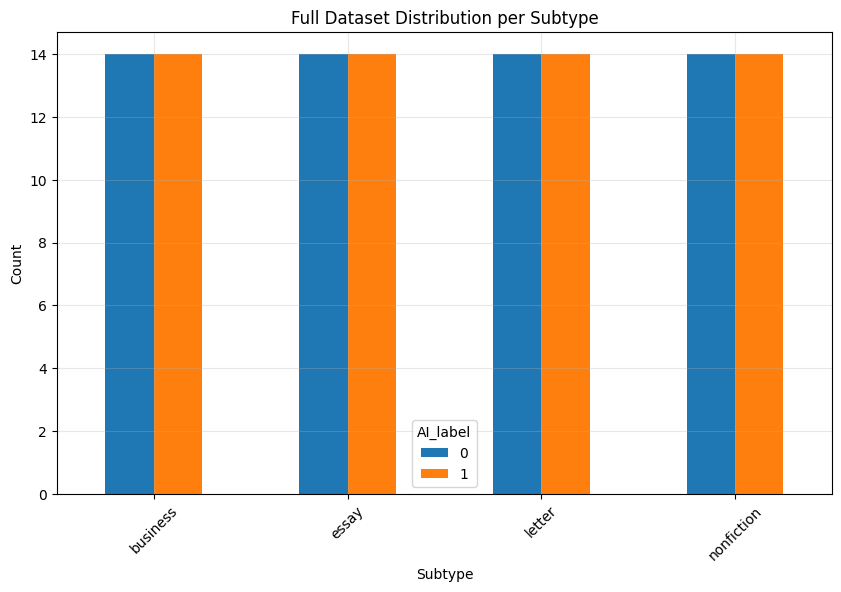

In [ ]:
# visuals (for report)
subtype_counts.plot(kind="bar", figsize=(10,6))
plt.title("Full Dataset Distribution per Subtype")
plt.xlabel("Subtype")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

# Informal Train + Evaluation for Hung and Mahla

Jeffrey's Optuna setup

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-small",
    num_labels=2,
    id2label={0: "Human-Written", 1: "AI-Generated"},
    label2id={"Human-Written": 0, "AI-Generated": 1},
    dtype=torch.float32
)

final_training_args = TrainingArguments(
    seed=42,
    output_dir="./deberta_v3_best",

    # Optuna Best Parameters
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=1.0317e-05,
    weight_decay=0.02586,
    warmup_steps=114,
    label_smoothing_factor=0.04114,

    lr_scheduler_type="cosine",
    optim="adamw_torch_fused" if torch.cuda.is_available() else "adamw_torch",
    adam_epsilon=1e-6,
    max_grad_norm=0.5,

    fp16=False,
    bf16=torch.cuda.is_bf16_supported(),

    eval_strategy="steps",
    eval_steps=45,
    save_strategy="steps",
    save_steps=45,
    save_total_limit=1,
    logging_steps=15,

    metric_for_best_model="accuracy",
    greater_is_better=True,
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=final_training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["val"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
)

# Run full final training run
trainer.train()

# Save final tuned model weights and tokenizer
trainer.save_model("./deberta_v3_informal")
tokenizer.save_pretrained("./deberta_v3_informal_fin")

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifie

Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,Auc
45,0.696326,0.691998,0.501852,0.334155,0.335393,0.250926,0.500000,0.877653
90,0.677965,0.662460,0.937037,0.937029,0.937032,0.937153,0.937009,0.981589
135,0.315722,0.224563,0.966667,0.966657,0.966659,0.967022,0.966618,0.993806
180,0.144418,0.243847,0.952778,0.952703,0.952696,0.956099,0.952938,0.988292
225,0.106731,0.187101,0.971296,0.971283,0.971281,0.972395,0.971388,0.992508
270,0.105789,0.129052,0.990741,0.990741,0.990741,0.990754,0.990754,0.995974
315,0.112266,0.135015,0.987963,0.987963,0.987963,0.988022,0.987987,0.995470
360,0.131499,0.147144,0.982407,0.982406,0.982406,0.982645,0.982452,0.992995
405,0.119435,0.169873,0.976852,0.976846,0.976845,0.977508,0.976924,0.991238
450,0.102830,0.133706,0.988889,0.988889,0.988889,0.988929,0.988909,0.994194


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./deberta_v3_informal_fin\\tokenizer_config.json',
 './deberta_v3_informal_fin\\tokenizer.json')

In [ ]:
# tokenizing the external evaluation set
external_df = pd.read_csv("outsideval_informal_samples.csv", encoding="Latin-1") # evaluation set
external_dataset = Dataset.from_pandas(external_df)

checkpoint_dir = r".\deberta_v3_best\checkpoint-270" # folder to model you're loading
tokenizer = AutoTokenizer.from_pretrained(checkpoint_dir)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint_dir,dtype=torch.float32)
model.eval()

MAX_LENGTH = 350 # make sure this value matches the max length used by the model you're evaluating

def tokenize(example):
  tokenized = tokenizer(example["sample_text"], truncation=True, padding="max_length", max_length=MAX_LENGTH)
  tokenized["labels"] = example["AI_label"]
  return tokenized

tokenized_external_dataset = external_dataset.map(
    tokenize,
    batched=True,
    remove_columns=external_dataset.column_names,
)

eval_args = TrainingArguments(
    output_dir="./tmp_eval",
    per_device_eval_batch_size=32,
    report_to="none",
)

eval_trainer = Trainer(
    model=model,
    args=eval_args,
)

preds_output = eval_trainer.predict(tokenized_external_dataset)
logits = preds_output.predictions
labels = preds_output.label_ids

probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
prob_ai = probs[:, 1]  # P(AI-generated) — this is what roc_auc_score needs as y_score
predicted_classes = np.argmax(logits, axis=-1)

# quick metric breakdown

print("True label distribution:", Counter(labels.tolist()))
print("Predicted label distribution:", Counter(predicted_classes.tolist()))

print("AUC:", roc_auc_score(labels, prob_ai))
print("F1:", f1_score(labels, predicted_classes))

print("Confusion matrix:\n", confusion_matrix(labels, predicted_classes))
print(external_df["AI_label"].value_counts())

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

Map:   0%|          | 0/1350 [00:00<?, ? examples/s]

True label distribution: Counter({0: 675, 1: 675})
Predicted label distribution: Counter({0: 1350})
AUC: 0.37400823045267495
F1: 0.0
Confusion matrix:
 [[675   0]
 [675   0]]


In [ ]:
results_df = pd.DataFrame({
    "text": external_df["sample_text"].values,
    "true_label": labels,
    "pred_label": predicted_classes,
    "prob_ai": prob_ai,
    "sub-type": external_df["sub-type"].values if "sub-type" in external_df.columns else None,
})